# Control Systems Playground

## Table of Contents

- [1. First Order Systems](#1-first-order-systems)

- [2. Second Order Systems](#2-second-order-systems)

- [3. Filters](#3-filters)
    - [Low Pass](#31-low-pass)
    - [High Pass](#32-high-pass)
    - [Band Pass](#33-band-pass)
    - [Band Stop](#34-band-stop)

- [5. Interactive Playground](#5-interactive-playground)

In [1]:
%load_ext autoreload
%autoreload 2
# Imports
import control_utils as cu
import signals as sig
import plotting as plot

## 1. First Order Systems
$$
H(s) = \frac{1}{\tau s + 1}
$$

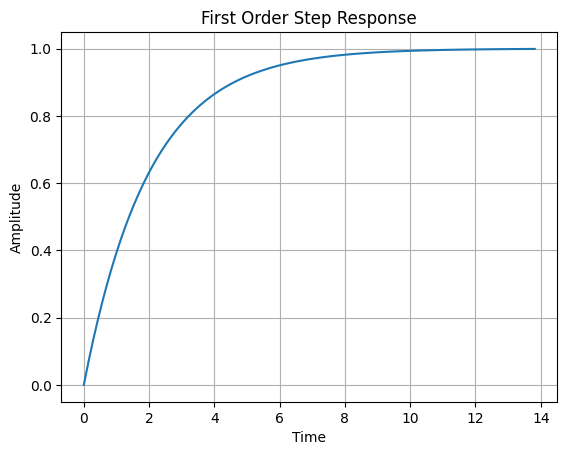

In [6]:
sys = cu.first_order(k=1, tau=2)

t, y = cu.step_response(sys)
plot.plot_time(t, y, "First Order Step Response")

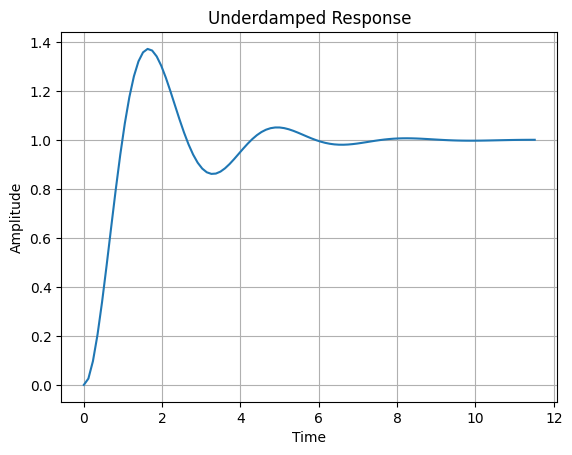

In [3]:
# Second Order System
sys = cu.second_order(wn=2, zeta=0.3)

t, y = cu.step_response(sys)
plot.plot_time(t, y, "Underdamped Response")

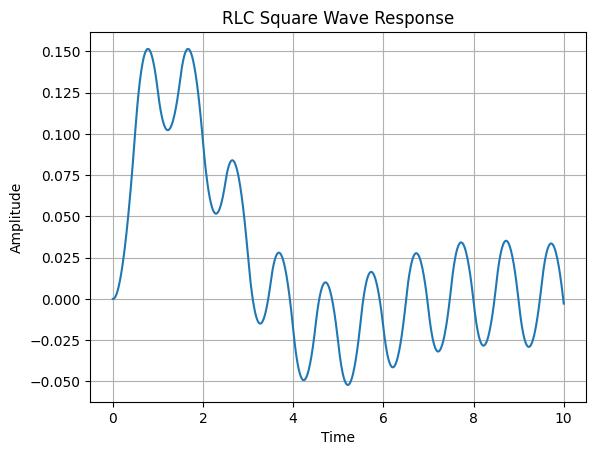

In [4]:
# RLC System
sys = cu.rlc_series(R=1, L=1, C=1)

t = sig.time_vector()
u = sig.square_wave(t)

t, y = cu.forced_response(sys, t, u)
plot.plot_time(t, y, "RLC Square Wave Response")

In [5]:
# Interactive Playground
import ipywidgets as widgets

def playground(a=1, b=1):
    sys = cu.make_TransferFunction([1,0,a**2], [1, 2*a*b, a**2])
    
    t, y = cu.step_response(sys)
    plot.plot_time(t, y, f"a={a}, b={b}")

widgets.interact(
    playground,
    k=(0.1, 10, 0.1),
    a=(0.1, 10, 0.1),
    b=(0.1, 10, 0.1)
)

interactive(children=(FloatSlider(value=1.0, description='a', max=10.0, min=0.1), FloatSlider(value=1.0, descr…

<function __main__.playground(a=1, b=1)>